
# 06_multimodal_feature_store.ipynb

## Enterprise Multimodal Feature Store

This notebook converts multimodal product intelligence into:
- retrieval-ready feature systems
- BI-ready analytical tables
- vector-search infrastructure
- enterprise feature registries

---

## Core Objectives

### Feature Store Layers
- image-level features
- product-level features
- retrieval features
- ranking features

### Retrieval Infrastructure
- ANN-ready embeddings
- semantic similarity indices
- queryable metadata

### Business Intelligence
- product health scores
- catalog quality metrics
- seller-quality proxies
- duplicate analytics

### Enterprise Exports
- feature stores
- vector stores
- feature registries
- health reports


In [1]:

!pip install -q pyarrow scikit-learn faiss-gpu-cu12


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 31.5 MB/s eta 0:00:00


In [2]:

import os
import gc
import json
import warnings

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from collections import Counter

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)


In [3]:

BASE_DIR = "/kaggle/working"

FEATURE_STORE_DIR = (
    f"{BASE_DIR}/multimodal_feature_store"
)

os.makedirs(
    FEATURE_STORE_DIR,
    exist_ok=True
)

print(FEATURE_STORE_DIR)


/kaggle/working/multimodal_feature_store



# Stage 1 — Load Product Fusion Outputs


In [4]:

product_df = pd.read_parquet(

    "/kaggle/input/notebooks/hanafudaearring/multimodal-product-fusion/multimodal_product_fusion_final/product_feature_store.parquet"
)

retrieval_df = pd.read_parquet(

    "/kaggle/input/notebooks/hanafudaearring/multimodal-product-fusion/multimodal_product_fusion_final/product_retrieval_index.parquet"
)

product_embeddings = np.load(

    "/kaggle/input/notebooks/hanafudaearring/multimodal-product-fusion/multimodal_product_fusion_final/product_embeddings.npy"
)

print(
    "PRODUCT DF:",
    product_df.shape
)

print(
    "RETRIEVAL DF:",
    retrieval_df.shape
)

print(
    "EMBEDDINGS:",
    product_embeddings.shape
)


PRODUCT DF: (728, 17)
RETRIEVAL DF: (728, 3)
EMBEDDINGS: (728, 512)


In [5]:

product_df.head()


,asin,image_count,avg_quality_score,avg_embedding_health,avg_media_score,duplicate_ratio,color_diversity,style_diversity,logo_density,dominant_color,dominant_visual_category,top_styles,detected_logos,merged_caption,visual_uniqueness,fused_embedding,product_intelligence_score
0,B00021NY28,6,0.356888,0.595175,0.462246,0.0,3,0,0.000000,white,unknown,[],[],a woman in a white top and black pants | a wom...,NaN,"[0.017875921, 0.02697452, -0.032951687, -0.005...",0.603577
1,B0006U6C0Q,7,0.331323,0.622507,0.490208,0.0,4,0,0.000000,white,unknown,[],[],a man in a blue shirt and jeans | a man in a b...,NaN,"[0.014319795, 0.020532222, -0.022347748, -0.00...",0.611010
2,B0007CKJSY,7,0.287760,0.616898,0.508821,0.0,4,0,0.000000,white,unknown,[],[],wr men ' s wr wr wr wr wr wr wr wr wr wr wr wr...,NaN,"[0.0085501205, 0.01536036, -0.01711279, -0.010...",0.603370
3,B0008EOG9E,3,0.384456,0.573370,0.403791,1.0,2,0,0.666667,white,unknown,[],[],"levi levi men ' s regular fit jeans, blue, 34w...",NaN,"[0.0031577311, 0.022369334, -0.0078112525, 0.0...",0.340404
4,B0008EOGAS,3,0.384456,0.576210,0.404737,1.0,2,0,0.666667,white,unknown,[],[],"levi levi men ' s regular fit jeans, blue, 34w...",NaN,"[0.008239375, 0.020316346, -0.0069890865, 0.01...",0.341351



# Stage 2 — Feature Registry


In [6]:

feature_registry = {

    "identity_features": [

        "asin",
        "dominant_visual_category",
        "dominant_color"
    ],

    "quality_features": [

        "avg_quality_score",
        "avg_embedding_health",
        "avg_media_score",
        "product_intelligence_score"
    ],

    "diversity_features": [

        "image_count",
        "color_diversity",
        "style_diversity"
    ],

    "forensic_features": [

        "duplicate_ratio",
        "logo_density",
        "visual_uniqueness"
    ],

    "semantic_features": [

        "top_styles",
        "top_attributes",
        "detected_logos"
    ],

    "embedding_features": [

        "fused_embedding"
    ]
}

feature_registry


{'identity_features': ['asin', 'dominant_visual_category', 'dominant_color'],
 'quality_features': ['avg_quality_score',
  'avg_embedding_health',
  'avg_media_score',
  'product_intelligence_score'],
 'diversity_features': ['image_count', 'color_diversity', 'style_diversity'],
 'forensic_features': ['duplicate_ratio', 'logo_density', 'visual_uniqueness'],
 'semantic_features': ['top_styles', 'top_attributes', 'detected_logos'],
 'embedding_features': ['fused_embedding']}

In [7]:

with open(

    f"{FEATURE_STORE_DIR}/feature_registry.json",

    "w"

) as f:

    json.dump(
        feature_registry,
        f,
        indent=4
    )

print(
    "FEATURE REGISTRY EXPORTED"
)


FEATURE REGISTRY EXPORTED



# Stage 3 — Foreground-Aware Color Correction


In [8]:

BACKGROUND_COLORS = [
    "white",
    "gray"
]

product_df["foreground_color"] = (

    product_df[
        "dominant_color"
    ].apply(

        lambda x:

        "unknown"

        if x in BACKGROUND_COLORS

        else x
    )
)

product_df[[
    "dominant_color",
    "foreground_color"
]].head()


,dominant_color,foreground_color
0,white,unknown
1,white,unknown
2,white,unknown
3,white,unknown
4,white,unknown



# Stage 4 — Product Health Intelligence


In [9]:

scaler = MinMaxScaler()

health_inputs = product_df[[

    "avg_quality_score",

    "avg_embedding_health",

    "avg_media_score",

    "color_diversity",

    "style_diversity"
]].fillna(0)

scaled_health = scaler.fit_transform(
    health_inputs
)

product_df["catalog_health_score"] = (
    scaled_health.mean(axis=1)
)


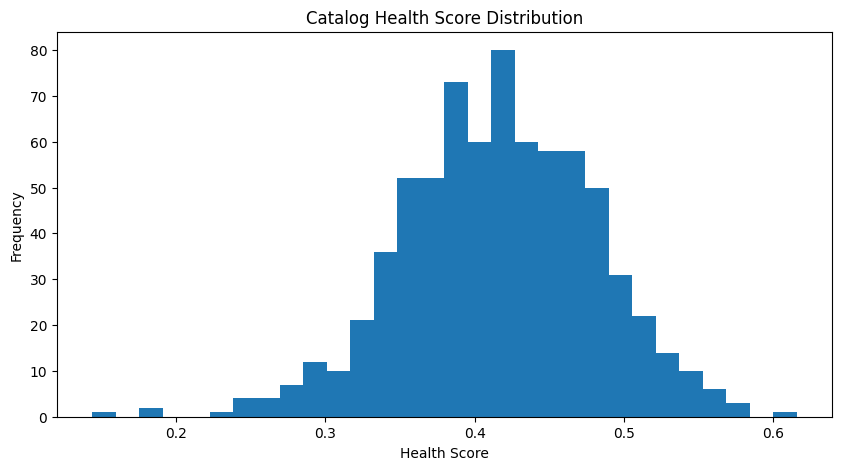

In [10]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "catalog_health_score"
    ],

    bins=30
)

plt.title(
    "Catalog Health Score Distribution"
)

plt.xlabel("Health Score")
plt.ylabel("Frequency")

plt.show()



# Stage 5 — Retrieval Intelligence


In [11]:

similarity_matrix = cosine_similarity(
    product_embeddings
)

similarity_matrix.shape


(728, 728)

In [12]:

retrieval_quality_scores = []

for idx in range(
    len(product_df)
):

    sims = similarity_matrix[idx]

    retrieval_quality_scores.append(

        float(
            np.mean(
                np.sort(sims)[-6:-1]
            )
        )
    )

product_df[
    "retrieval_quality_score"
] = retrieval_quality_scores


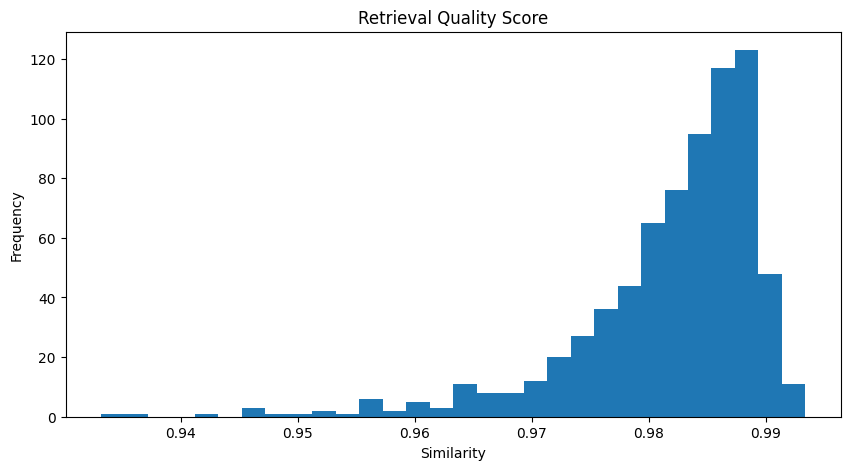

In [13]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "retrieval_quality_score"
    ],

    bins=30
)

plt.title(
    "Retrieval Quality Score"
)

plt.xlabel("Similarity")
plt.ylabel("Frequency")

plt.show()



# Stage 6 — Duplicate Intelligence


In [14]:

product_df["duplicate_risk"] = (

    product_df[
        "duplicate_ratio"
    ].apply(

        lambda x:

        "high"
        if x > 0.75

        else (

            "medium"
            if x > 0.3

            else "low"
        )
    )
)


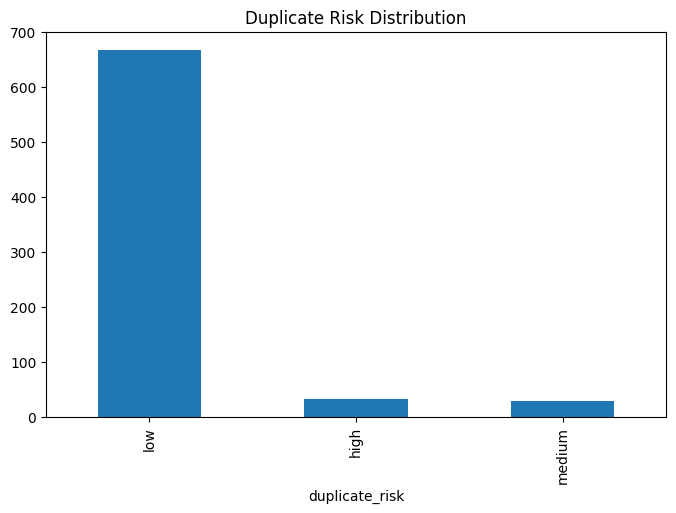

In [15]:

product_df[
    "duplicate_risk"
].value_counts().plot.bar(
    figsize=(8,5)
)

plt.title(
    "Duplicate Risk Distribution"
)

plt.show()



# Stage 7 — Semantic Richness Intelligence


In [16]:

product_df["semantic_richness"] = (

    product_df[
        "style_diversity"
    ].fillna(0)

    +

    product_df[
        "color_diversity"
    ].fillna(0)

    +

    product_df[
        "logo_density"
    ].fillna(0)
)


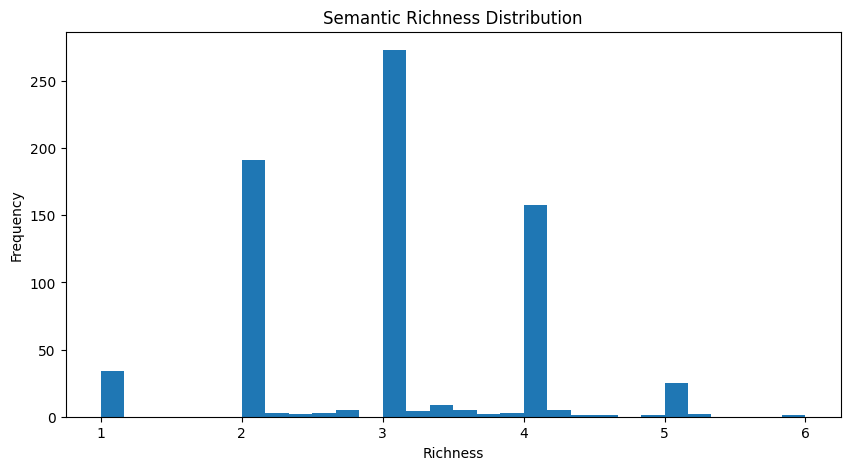

In [17]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "semantic_richness"
    ],

    bins=30
)

plt.title(
    "Semantic Richness Distribution"
)

plt.xlabel("Richness")
plt.ylabel("Frequency")

plt.show()



# Stage 8 — Enterprise Retrieval Store


In [18]:

retrieval_store = product_df[[

    "asin",

    "dominant_visual_category",

    "foreground_color",

    "catalog_health_score",

    "retrieval_quality_score",

    "semantic_richness",

    "merged_caption"
]].copy()

retrieval_store.head()


,asin,dominant_visual_category,foreground_color,catalog_health_score,retrieval_quality_score,semantic_richness,merged_caption
0,B00021NY28,unknown,unknown,0.420660,0.988417,3.000000,a woman in a white top and black pants | a wom...
1,B0006U6C0Q,unknown,unknown,0.471241,0.989680,4.000000,a man in a blue shirt and jeans | a man in a b...
2,B0007CKJSY,unknown,unknown,0.443865,0.988481,4.000000,wr men ' s wr wr wr wr wr wr wr wr wr wr wr wr...
3,B0008EOG9E,unknown,unknown,0.355698,0.978450,2.666667,"levi levi men ' s regular fit jeans, blue, 34w..."
4,B0008EOGAS,unknown,unknown,0.357776,0.982514,2.666667,"levi levi men ' s regular fit jeans, blue, 34w..."



# Stage 9 — ANN-Ready Vector Store


In [19]:

embedding_store = {

    asin: embedding

    for asin, embedding in zip(

        product_df["asin"],

        product_embeddings
    )
}

len(embedding_store)


728


# Stage 10 — Product Intelligence Ranking


In [20]:

ranking_features = product_df[[

    "catalog_health_score",

    "retrieval_quality_score",

    "semantic_richness"
]].fillna(0)

product_df["enterprise_product_score"] = (

    ranking_features.mean(axis=1)
)


In [21]:

top_products = product_df.sort_values(

    "enterprise_product_score",

    ascending=False
)

top_products[[

    "asin",

    "enterprise_product_score",

    "dominant_visual_category",

    "foreground_color"

]].head(20)


,asin,enterprise_product_score,dominant_visual_category,foreground_color
620,B0CY29F6G4,2.508264,unknown,unknown
347,B098KXZG2Z,2.227688,unknown,purple
714,B0DRXCWRYM,2.220622,unknown,black
256,B085NF55WL,2.188983,unknown,unknown
94,B06VZ3RCYS,2.183557,unknown,black
125,B077SVB38N,2.182869,unknown,pink
234,B07VTSD48H,2.180450,unknown,pink
328,B08Z755PCH,2.178966,unknown,unknown
721,B0DSW6C8PT,2.171436,unknown,unknown
449,B0BGSDG377,2.171188,unknown,unknown


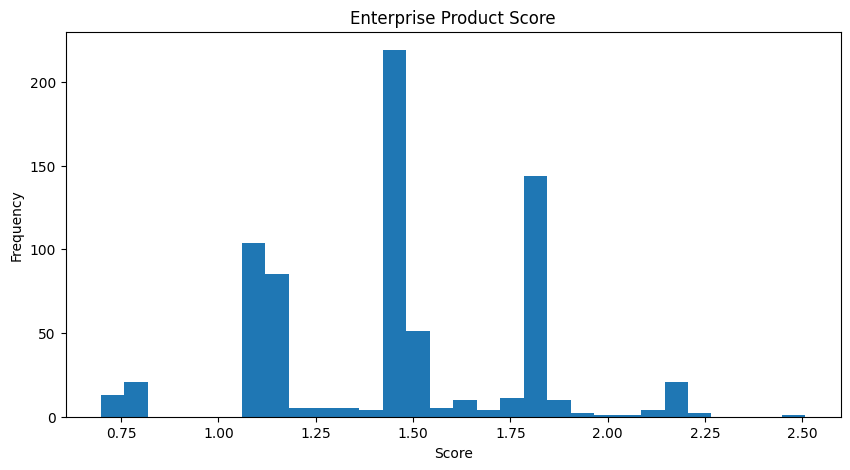

In [22]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "enterprise_product_score"
    ],

    bins=30
)

plt.title(
    "Enterprise Product Score"
)

plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()



# Stage 11 — BI Feature Tables


In [23]:

category_bi = product_df.groupby(

    "dominant_visual_category"

).agg({

    "catalog_health_score": "mean",

    "retrieval_quality_score": "mean",

    "semantic_richness": "mean",

    "asin": "count"
}).rename(columns={

    "asin": "product_count"
})

category_bi


,catalog_health_score,retrieval_quality_score,semantic_richness,product_count
dominant_visual_category,,,,
unknown,0.415703,0.981808,2.964024,728


In [24]:

color_bi = product_df.groupby(

    "foreground_color"

).agg({

    "catalog_health_score": "mean",

    "asin": "count"
}).rename(columns={

    "asin": "product_count"
})

color_bi


,catalog_health_score,product_count
foreground_color,,
black,0.423880,103
brown,0.413276,19
green,0.372968,3
orange,0.327914,2
pink,0.423357,99
purple,0.525964,1
unknown,0.412988,501



# Stage 12 — Feature Store Exports


In [25]:

product_df.to_parquet(

    f"{FEATURE_STORE_DIR}/enterprise_product_feature_store.parquet",

    index=False
)

print(
    "EXPORTED PRODUCT FEATURE STORE"
)


EXPORTED PRODUCT FEATURE STORE


In [26]:

retrieval_store.to_parquet(

    f"{FEATURE_STORE_DIR}/retrieval_feature_store.parquet",

    index=False
)

print(
    "EXPORTED RETRIEVAL STORE"
)


EXPORTED RETRIEVAL STORE


In [27]:

category_bi.to_parquet(

    f"{FEATURE_STORE_DIR}/category_bi.parquet"
)

color_bi.to_parquet(

    f"{FEATURE_STORE_DIR}/color_bi.parquet"
)

print(
    "EXPORTED BI TABLES"
)


EXPORTED BI TABLES


In [28]:

np.save(

    f"{FEATURE_STORE_DIR}/enterprise_product_embeddings.npy",

    product_embeddings
)

print(
    "EXPORTED EMBEDDINGS"
)


EXPORTED EMBEDDINGS



# Stage 13 — Feature Store Health Report


In [29]:

health_report = {

    "total_products":
        int(len(product_df)),

    "embedding_dimension":
        int(product_embeddings.shape[1]),

    "categories":
        int(
            product_df[
                "dominant_visual_category"
            ].nunique()
        ),

    "foreground_colors":
        int(
            product_df[
                "foreground_color"
            ].nunique()
        ),

    "high_duplicate_risk_products":
        int(
            (
                product_df[
                    "duplicate_risk"
                ] == "high"
            ).sum()
        )
}

health_report


{'total_products': 728,
 'embedding_dimension': 512,
 'categories': 1,
 'foreground_colors': 7,
 'high_duplicate_risk_products': 32}

In [30]:

with open(

    f"{FEATURE_STORE_DIR}/feature_store_health_report.json",

    "w"

) as f:

    json.dump(
        health_report,
        f,
        indent=4
    )

print("=" * 60)

print(
    "MULTIMODAL FEATURE STORE COMPLETE"
)

print("=" * 60)

print(
    "TOTAL PRODUCTS:",
    len(product_df)
)

print(
    "EMBEDDING DIM:",
    product_embeddings.shape[1]
)

print(
    "CATEGORIES:",
    product_df[
        "dominant_visual_category"
    ].nunique()
)

print("=" * 60)


MULTIMODAL FEATURE STORE COMPLETE
TOTAL PRODUCTS: 728
EMBEDDING DIM: 512
CATEGORIES: 1
